<a href="https://colab.research.google.com/github/FasterThanAi/ML_Projects/blob/main/RNN_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

In [2]:
sentences = [
 "I love this product",
 "This movie made me smile",
 "Service was friendly and quick",
 "Today felt bright and happy",
 "This is the best day",
 "Absolutely fantastic experience",
 "I enjoyed every single moment",
 "Great job, well done",
 "The food tasted delicious",
 "Totally recommend to everyone",
 "Very satisfied with results",
 "This worked better than expected",
 "Amazing quality and value",
 "Such a pleasant surprise",
 "I feel positive about this",
 "I hate this product",
 "This movie bored me",
 "Service was rude and slow",
 "Today was cold and lonely",
 "This is the worst day",
 "Terrible experience overall",
 "I regret buying this",
 "Very disappointed with results",
 "The food tasted awful",
 "Do not recommend this",
 "It broke after one use",
 "Not worth the money",
 "Utterly frustrating and annoying",
 "I feel negative about this",
 "Such a waste of time",
]
labels = [1]*15 + [0]*15
labels = np.array(labels)

In [3]:
vocab_size=2000
tok=Tokenizer(num_words=vocab_size,oov_token="<oov>")
tok.fit_on_texts(sentences)
seqs=tok.texts_to_sequences(sentences)
maxlen=max(len(s) for s in seqs)
X=pad_sequences(seqs,maxlen=maxlen,padding="post")
y=labels


In [4]:
maxlen

5

In [5]:
X[29]

array([21, 22, 85, 86, 87], dtype=int32)

model creation of RNN
dimensions batna padta h

In [6]:
embed_dim=16
rnn_units=8 #hidden layer no.

In [8]:
inp=Input(shape={maxlen,},dtype="int32",name='input')
x=Embedding(input_dim=vocab_size,output_dim=embed_dim,mask_zero=True,name='embed')(inp)
rnn=SimpleRNN(units=rnn_units,return_sequences=False,return_state=False,name='simple_rnn')
#output layer
x_last=rnn(x)
out=Dense(1,activation='sigmoid',name='out')(x_last)
model=Model(inputs=inp,outputs=out)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 5, 16)     │     32,000 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 5)         │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        200 │ embed[0][0],      │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │          9 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,209 (125.82 KB)

 Trainable params: 32,209 (125.82 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(X,y,epochs=25,batch_size=8,verbose=1)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4333 - loss: 0.6952
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5333 - loss: 0.6803 
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7333 - loss: 0.6672
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7667 - loss: 0.6542
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8667 - loss: 0.6412
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9000 - loss: 0.6274
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9000 - loss: 0.6131
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9333 - loss: 0.5979
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9333 - loss: 0.5820
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9333 - loss: 0.5650
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9667 - loss: 0.5478
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9667 - loss: 0.5290


### Visualizing Embeddings and Hidden States

To understand what the model is learning, we can visualize the activations of the `Embedding` layer and the `SimpleRNN` layer. For the `SimpleRNN` layer, we will create a new model that outputs the sequence of hidden states (by setting `return_sequences=True`).

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the input layer
input_layer_vis = Input(shape=(maxlen,), dtype="int32", name='input_vis')

# Get the weights from the trained model's embedding layer
embedding_layer_weights = model.get_layer('embed').get_weights()

# Create a new Embedding layer for visualization, using the trained weights
embedding_output_vis = Embedding(
    input_dim=vocab_size,
    output_dim=embed_dim,
    mask_zero=True,
    name='embed_vis',
    weights=embedding_layer_weights
)(input_layer_vis)

# Get the weights from the trained model's SimpleRNN layer
rnn_layer_weights = model.get_layer('simple_rnn').get_weights()

# Create a SimpleRNN layer for visualization, returning sequences,
# and then set the trained weights
rnn_layer_vis = SimpleRNN(
    units=rnn_units,
    return_sequences=True, # Set to True to get hidden states at each timestep
    return_state=False,
    name='simple_rnn_vis'
)
rnn_layer_vis.build(embedding_output_vis.shape) # Corrected: pass shape as positional argument
rnn_layer_vis.set_weights(rnn_layer_weights)
rnn_output_vis = rnn_layer_vis(embedding_output_vis)

# Create a visualization model that outputs embeddings and RNN sequences
visualization_model = Model(inputs=input_layer_vis, outputs=[embedding_output_vis, rnn_output_vis])

visualization_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_vis           │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_vis           │ (None, 5, 16)     │     32,000 │ input_vis[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 5)         │          0 │ input_vis[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_vis      │ (None, 5, 8)      │        200 │ embed_vis[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal_4[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,200 (125.78 KB)

 Trainable params: 32,200 (125.78 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Choose a sample sentence for visualization
sample_sentence_idx = 0 # "I love this product"
sample_input_text = sentences[sample_sentence_idx]
sample_input_sequence = X[sample_sentence_idx:sample_sentence_idx+1]

# Get the embeddings and hidden states for the sample sentence
embeddings_output, hidden_states_output = visualization_model.predict(sample_input_sequence)

# Squeeze the batch dimension for plotting
embeddings_output = embeddings_output.squeeze()
hidden_states_output = hidden_states_output.squeeze()

print(f"Sample sentence: '{sample_input_text}'")
print(f"Shape of embeddings output: {embeddings_output.shape}")
print(f"Shape of hidden states output: {hidden_states_output.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
Sample sentence: 'I love this product'
Shape of embeddings output: (5, 16)
Shape of hidden states output: (5, 8)


#### Visualization of Embeddings (Pre-time stamps)

This heatmap shows the embedding vectors for each word in the sample sentence. Each row represents a word (or padding token), and each column represents a dimension in the embedding space.

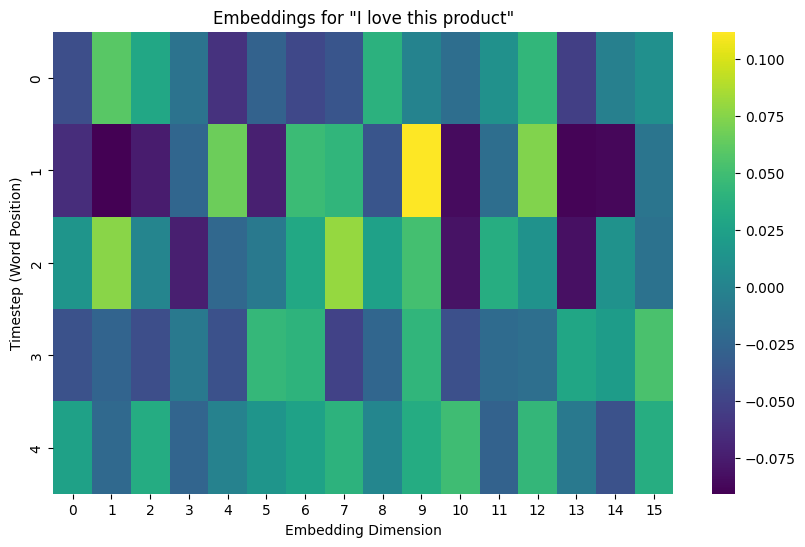

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(embeddings_output, cmap='viridis', annot=False)
plt.title(f'Embeddings for "{sample_input_text}"')
plt.xlabel('Embedding Dimension')
plt.ylabel('Timestep (Word Position)')
plt.show()

#### Visualization of Hidden States (Hidden Stats)

This heatmap illustrates how the RNN's hidden state evolves at each timestep as it processes the input sequence. Each row corresponds to a timestep (word), and each column is a unit in the RNN's hidden layer.

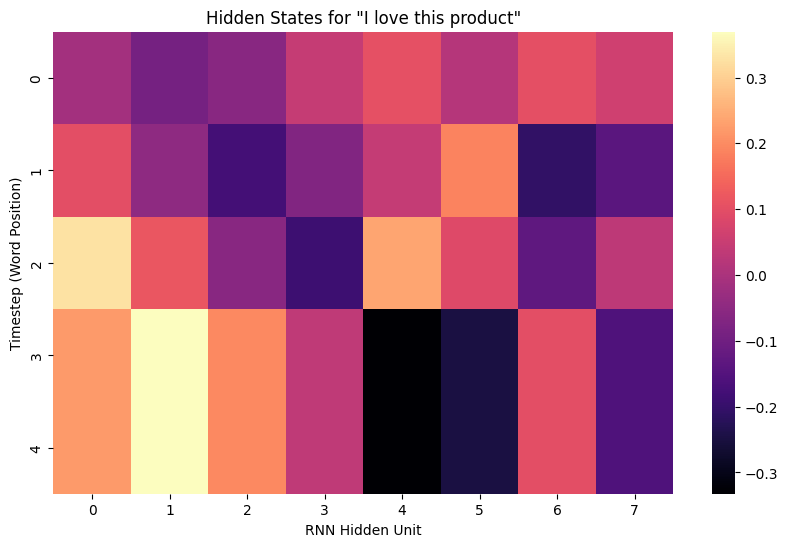

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(hidden_states_output, cmap='magma', annot=False)
plt.title(f'Hidden States for "{sample_input_text}"')
plt.xlabel('RNN Hidden Unit')
plt.ylabel('Timestep (Word Position)')
plt.show()